# Ассоциация скорости назначения слота и конверсий воронки

## Назначение

Оценка **условной ассоциации** между временем до первого доступного интервала (`t_available`) и исходами воронки (`sch_flg`, `meet_flg`, `success_within_20`, `utlz_within_25`). Методы: описательные профили по децилям, корреляции Пирсона/Спирмена, hex×day FE-LPM (`PanelOLS`, кластеризация по гексагону).

## Входные данные

Заявки с наблюдаемым `start_interval`; для post-meeting исходов — фильтр зрелости и исключение когорты 2022-07-27; `utlz_within_25` с H=25.

## Результаты

- `outputs/final/speed_conversion_association_summary.csv`, `speed_conversion_fe_summary.csv`;
- графики в `figures/empirical/speed_conversion_*`.

## Статус

**Канонический расчёт** (ассоциация, **не** каузальный эффект скорости).

In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

cwd = Path.cwd().resolve()
if cwd.name.lower() in {"notebooks", "notebook"}:
    PROJECT_ROOT = cwd.parents[0]
elif (cwd / "last_mile").exists():
    PROJECT_ROOT = cwd
else:
    PROJECT_ROOT = cwd.parents[0]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

FIG_DIR = PROJECT_ROOT / "figures" / "empirical"
OUT_FINAL = PROJECT_ROOT / "outputs" / "final"
DATA_RAW = PROJECT_ROOT / "data" / "raw"
APPLICATIONS_PATH = DATA_RAW / "application_dataset.csv"
HEXAGONS_PATH = DATA_RAW / "hexagons_dataset.csv"

FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_FINAL.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("APPLICATIONS_PATH exists:", APPLICATIONS_PATH.exists())
print("HEXAGONS_PATH exists:", HEXAGONS_PATH.exists())

PALETTE = {
    "blue_dark": "#1D4E89",
    "blue": "#4C91D9",
    "orange": "#D88C2D",
    "gray_dark": "#202833",
    "gray": "#747E8C",
    "gray_grid": "#E9EDF2",
    "paper": "#FFFFFF",
}

mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.unicode_minus": False,
    "pdf.fonttype": 42,
    "savefig.bbox": "tight",
})

EXPORT_DPI = 300

def save_figure(fig: plt.Figure, stem: str) -> None:
    pdf = FIG_DIR / f"{stem}.pdf"
    png = FIG_DIR / f"{stem}.png"
    fig.savefig(pdf, format="pdf")
    fig.savefig(png, format="png", dpi=EXPORT_DPI)
    print(f"saved: {pdf.relative_to(PROJECT_ROOT)}")
    print(f"saved: {png.relative_to(PROJECT_ROOT)}")

PROJECT_ROOT: <resolved relative to repository root>
APPLICATIONS_PATH exists: True
HEXAGONS_PATH exists: True


## Загрузка данных

Используем `last_mile.filter.build_did_samples` (или loaders) для подготовки заявок воздействия и контроля. При отсутствии сырых файлов ячейка завершится с понятной ошибкой; код остаётся корректным для полного прогона.

In [2]:
RAW_OK = APPLICATIONS_PATH.exists() and HEXAGONS_PATH.exists()
apps = pd.DataFrame()
LOAD_ERROR = None

if not RAW_OK:
    LOAD_ERROR = (
        f"Сырые данные не найдены:\n  {APPLICATIONS_PATH}\n  {HEXAGONS_PATH}\n"
        "Дальнейшие ячейки рассчитаны на полный прогон после появления data/raw/."
    )
    display(Markdown(f"**Предупреждение:** {LOAD_ERROR}"))
else:
    try:
        from last_mile.filter import build_did_samples, STUDY_END
        from last_mile.outcomes import success_horizon_coverage

        samples = build_did_samples(APPLICATIONS_PATH, HEXAGONS_PATH)
        apps_t = samples["apps_t"].copy()
        apps_c = samples["apps_c"].copy()
        apps_t["sample_arm"] = "treated"
        apps_c["sample_arm"] = "control"
        # unify columns for concat
        for col in ["treatment_date", "change_type", "days_from_treatment"]:
            if col not in apps_c.columns:
                apps_c[col] = pd.NaT if "date" in col or col == "treatment_date" else np.nan
        apps = pd.concat([apps_t, apps_c], ignore_index=True, sort=False)
        print("apps rows:", len(apps))
        print("OBS:", samples["obs_min"], "—", samples["obs_max"])
    except Exception as exc:  # noqa: BLE001 — dry-run / data issues
        LOAD_ERROR = repr(exc)
        display(Markdown(f"**Ошибка загрузки:** `{LOAD_ERROR}`"))
        print("Код оставлен корректным; выполните ноутбук при доступных raw-данных.")

Период наблюдений: 2022-04-01 - 2022-10-19
treated-заявок: 1477440 | control-заявок: 329877
treated-гексагонов с заявками: 28178 | control-гексагонов: 6884


[INFO] multi-treatment исключено: 15832


apps rows: 1807317
OBS: 2022-04-01 00:00:00 — 2022-10-19 00:00:00


## Определение `t_available` и выборки

- `t_available_days = (start_interval - request_timestamp)` в днях.
- В анализ ассоциации входят **только заявки с наблюдаемым** `start_interval` (ненулевой `t_available`).
- Отрицательные значения и экстремумы диагностируются и отфильтровываются (отрицательные → исключение; верхний хвост усекается для устойчивости описательных графиков, но в корреляциях/FE используется очищенная выборка без отрицательных).

### `utlz_within_25`
- горизонт H = 25 дней;
- отрицательные лаги утилизации отбрасываются;
- фильтр зрелости: `request_timestamp + 25d <= 2022-10-18`;
- для post-meeting исходов (`meet_flg`, `success_within_20`, `utlz_within_25`) исключается когорта `2022-07-27`; `success_within_20` оценивается только на mature-заявках.

In [3]:
UTLZ_H = 25
UTILIZATION_OBSERVATION_END = pd.Timestamp("2022-10-18")
EXCLUDED_COHORT_CONVERSION = pd.Timestamp("2022-07-27")
BINARY_OUTCOMES = [
    "sch_flg", "meet_flg", "success_within_20", "utlz_within_25"
]
POST_MEETING = {"meet_flg", "success_within_20", "utlz_within_25"}

summary_rows: list[dict] = []
assoc_base = pd.DataFrame()
assoc_utlz = pd.DataFrame()

if apps.empty:
    display(Markdown("Данные не загружены — пропускаем подготовку (dry-run)."))
else:
    df = apps.copy()
    df["request_timestamp"] = pd.to_datetime(df["request_timestamp"], errors="coerce")
    df, success_coverage = success_horizon_coverage(
        df, horizons=(20,), observation_end=UTILIZATION_OBSERVATION_END
    )
    if "start_interval" not in df.columns:
        raise KeyError("В данных нет колонки start_interval")
    df["start_interval"] = pd.to_datetime(df["start_interval"], errors="coerce")

    # t_available_days = (start_interval - request_timestamp) in days
    df["t_available_days"] = (
        df["start_interval"] - df["request_timestamp"]
    ).dt.total_seconds() / 86400.0

    n_total = len(df)
    n_obs_slot = int(df["start_interval"].notna().sum())
    n_neg = int((df["t_available_days"] < 0).fillna(False).sum())
    n_missing_t = int(df["t_available_days"].isna().sum())

    print(f"Всего заявок: {n_total:,}")
    print(f"С наблюдаемым start_interval: {n_obs_slot:,}")
    print(f"Отрицательный t_available: {n_neg:,}")
    print(f"Пропущенный t_available: {n_missing_t:,}")

    # Selection: only requests with observed start_interval and non-negative lag
    base = df.loc[df["start_interval"].notna() & df["t_available_days"].notna()].copy()
    base = base.loc[base["t_available_days"] >= 0].copy()

    q99 = float(base["t_available_days"].quantile(0.99))
    q999 = float(base["t_available_days"].quantile(0.999))
    print(
        f"t_available: mean={base['t_available_days'].mean():.3f}, "
        f"median={base['t_available_days'].median():.3f}, "
        f"p99={q99:.3f}, p99.9={q999:.3f}, max={base['t_available_days'].max():.3f}"
    )

    for col in ["sch_flg", "meet_flg", "success_flg", "utlz_flg"]:
        if col in base.columns:
            base[col] = pd.to_numeric(base[col], errors="coerce")

    if "date" not in base.columns:
        base["date"] = base["request_timestamp"].dt.normalize()
    if "treatment_date" in base.columns:
        base["treatment_date"] = pd.to_datetime(base["treatment_date"], errors="coerce")

    # utlz_within_25: H=25, drop negative lags, maturity request+25d <= 2022-10-18
    base_utlz = base.copy()
    if "real_utilization_dttm" in base_utlz.columns:
        base_utlz["real_utilization_dttm"] = pd.to_datetime(
            base_utlz["real_utilization_dttm"], errors="coerce"
        )
        neg_utlz = (
            base_utlz["real_utilization_dttm"].notna()
            & (base_utlz["real_utilization_dttm"] < base_utlz["request_timestamp"])
        )
        print(f"Отрицательный utilization lag: {int(neg_utlz.sum()):,}")
        base_utlz = base_utlz.loc[~neg_utlz].copy()
        horizon = base_utlz["request_timestamp"] + pd.Timedelta(days=UTLZ_H)
        base_utlz["utlz_within_25"] = (
            base_utlz["real_utilization_dttm"].notna()
            & (base_utlz["real_utilization_dttm"] <= horizon)
        ).astype(float)
        mature = (
            base_utlz["request_timestamp"] + pd.Timedelta(days=UTLZ_H)
            <= UTILIZATION_OBSERVATION_END
        )
        base_utlz = base_utlz.loc[mature].copy()
        print(f"utlz sample after maturity filter: {len(base_utlz):,}")
    else:
        base_utlz["utlz_within_25"] = np.nan
        print("Колонка real_utilization_dttm отсутствует — utlz_within_25 = NaN")

    base = base.drop(columns=["utlz_within_25"], errors="ignore")
    utlz_key = base_utlz[["hex", "request_timestamp", "utlz_within_25"]].drop_duplicates(
        subset=["hex", "request_timestamp"], keep="first"
    )
    base = base.merge(utlz_key, on=["hex", "request_timestamp"], how="left")

    assoc_base = base
    assoc_utlz = base_utlz

    summary_rows.extend(
        [
            {
                "section": "selection",
                "metric": "n_analysis_requests_before_t_available_filter",
                "outcome": "",
                "estimate": n_total,
                "std_error": np.nan,
                "p_value": np.nan,
                "n_obs": n_total,
                "note": "combined treated/control sample from build_did_samples; not the full raw dataset",
            },
            {
                "section": "selection",
                "metric": "n_with_start_interval_nonneg",
                "outcome": "",
                "estimate": len(base),
                "std_error": np.nan,
                "p_value": np.nan,
                "n_obs": len(base),
                "note": f"neg_dropped={n_neg}; p99={q99:.3f}",
            },
            {
                "section": "selection",
                "metric": "n_utlz_within_25_sample",
                "outcome": "utlz_within_25",
                "estimate": len(base_utlz),
                "std_error": np.nan,
                "p_value": np.nan,
                "n_obs": len(base_utlz),
                "note": f"H={UTLZ_H}; maturity end={UTILIZATION_OBSERVATION_END.date()}",
            },
        ]
    )


Всего заявок: 1,807,317
С наблюдаемым start_interval: 1,694,859
Отрицательный t_available: 0
Пропущенный t_available: 112,458


t_available: mean=2.671, median=2.000, p99=10.000, p99.9=19.000, max=48.000


Отрицательный utilization lag: 5,945


utlz sample after maturity filter: 1,470,084


## Описательная статистика

Распределение `t_available_days` и средние конверсии по децилям. Для post-meeting исходов применяется исключение когорты `2022-07-27`.

saved: figures\empirical\speed_conversion_t_available_dist.pdf
saved: figures\empirical\speed_conversion_t_available_dist.png


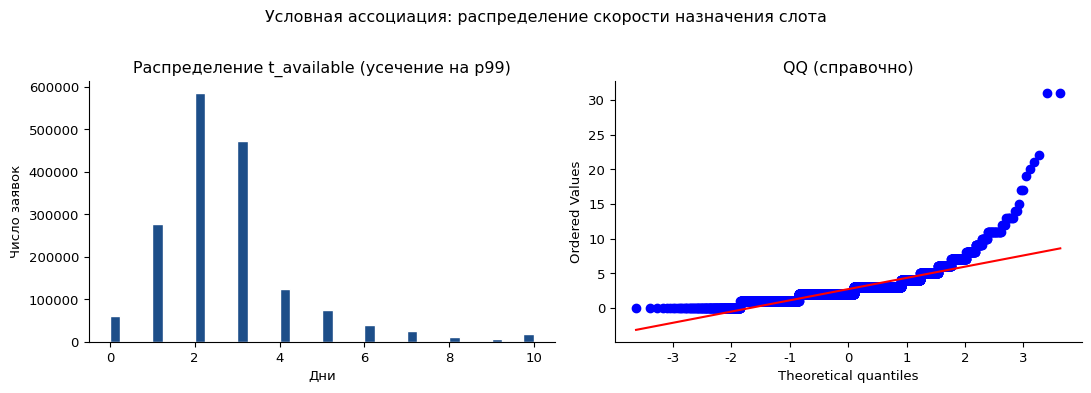

saved: figures\empirical\speed_conversion_by_decile.pdf
saved: figures\empirical\speed_conversion_by_decile.png


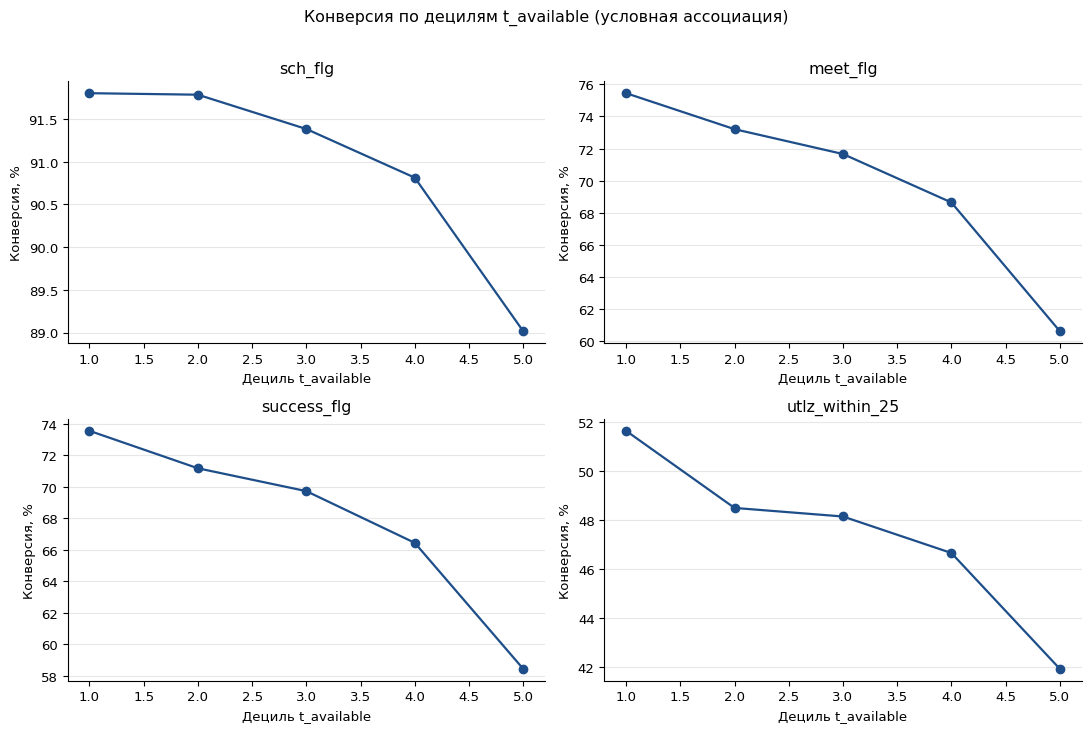

In [4]:
def outcome_sample(df: pd.DataFrame, outcome: str) -> pd.DataFrame:
    out = df.copy()
    if outcome == "utlz_within_25":
        out = out.loc[out["utlz_within_25"].notna()].copy()
    if outcome in POST_MEETING and "treatment_date" in out.columns:
        out = out.loc[
            out["treatment_date"].isna()
            | (out["treatment_date"] != EXCLUDED_COHORT_CONVERSION)
        ].copy()
    if outcome in out.columns:
        out = out.loc[out[outcome].notna()].copy()
    return out


if apps.empty:
    display(Markdown("Dry-run: описательные графики пропущены."))
else:
    # distribution
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
    t = assoc_base["t_available_days"]
    axes[0].hist(t.clip(upper=t.quantile(0.99)), bins=40, color=PALETTE["blue_dark"], edgecolor="white")
    axes[0].set_title("Распределение t_available (усечение на p99)")
    axes[0].set_xlabel("Дни")
    axes[0].set_ylabel("Число заявок")
    stats.probplot(t.sample(min(5000, len(t)), random_state=0), dist="norm", plot=axes[1])
    axes[1].set_title("QQ (справочно)")
    fig.suptitle("Условная ассоциация: распределение скорости назначения слота", y=1.02)
    fig.tight_layout()
    save_figure(fig, "speed_conversion_t_available_dist")
    plt.show()

    # conversion by deciles
    fig, axes = plt.subplots(2, 2, figsize=(11, 7.2))
    axes = axes.ravel()
    for ax, outcome in zip(axes, BINARY_OUTCOMES):
        s = outcome_sample(assoc_base if outcome != "utlz_within_25" else assoc_utlz, outcome)
        if s.empty or outcome not in s.columns:
            ax.set_title(outcome)
            ax.text(0.5, 0.5, "нет данных", ha="center", va="center", transform=ax.transAxes)
            continue
        s = s.copy()
        s["decile"] = pd.qcut(s["t_available_days"], 10, labels=False, duplicates="drop") + 1
        g = s.groupby("decile", as_index=False).agg(
            rate=(outcome, "mean"),
            n=(outcome, "count"),
            t_med=("t_available_days", "median"),
        )
        ax.plot(g["decile"], g["rate"] * 100, "o-", color=PALETTE["blue_dark"], linewidth=1.6)
        ax.set_title(outcome)
        ax.set_xlabel("Дециль t_available")
        ax.set_ylabel("Конверсия, %")
        ax.grid(True, axis="y", alpha=0.3)
        summary_rows.append({
            "section": "descriptive_decile",
            "metric": "conversion_spread_pp",
            "outcome": outcome,
            "estimate": float((g["rate"].max() - g["rate"].min()) * 100),
            "std_error": np.nan,
            "p_value": np.nan,
            "n_obs": int(g["n"].sum()),
            "note": "max_decile_rate - min_decile_rate, percentage points",
        })
    fig.suptitle("Конверсия по децилям t_available (условная ассоциация)", y=1.01)
    fig.tight_layout()
    save_figure(fig, "speed_conversion_by_decile")
    plt.show()

## Корреляции

Пирсон (для бинарного Y — point-biserial) и Спирмен; сообщаются коэффициент, двусторонний p-value и N. Интерпретация — **условная ассоциация**, не причинный эффект.

       section                 metric         outcome  estimate  std_error  p_value    n_obs                          note
0  correlation  pearson_pointbiserial         sch_flg   -0.0230        NaN   0.0000  1694859  association only; not causal
1  correlation               spearman         sch_flg   -0.0174        NaN   0.0000  1694859  association only; not causal
2  correlation  pearson_pointbiserial        meet_flg   -0.1074        NaN   0.0000  1665322  association only; not causal
3  correlation               spearman        meet_flg   -0.0774        NaN   0.0000  1665322  association only; not causal
4  correlation  pearson_pointbiserial     success_flg   -0.1064        NaN   0.0000  1665322  association only; not causal
5  correlation               spearman     success_flg   -0.0773        NaN   0.0000  1665322  association only; not causal
6  correlation  pearson_pointbiserial  utlz_within_25   -0.0581        NaN   0.0000  1443638  association only; not causal
7  correlation  

saved: figures\empirical\speed_conversion_correlations.pdf
saved: figures\empirical\speed_conversion_correlations.png


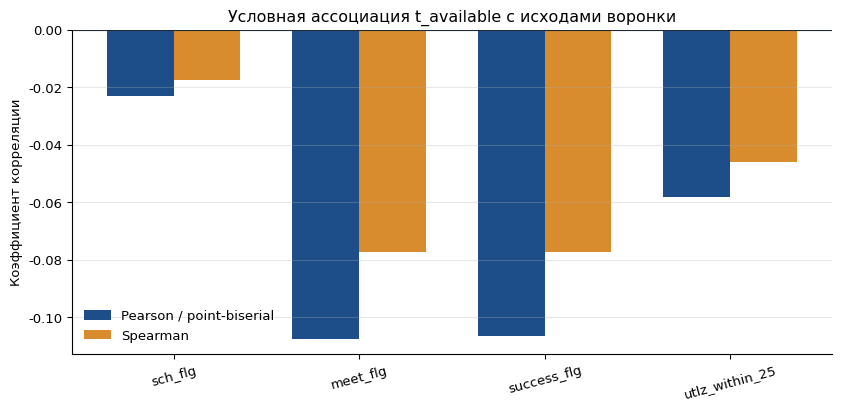

In [5]:
corr_rows = []

if apps.empty:
    display(Markdown("Dry-run: корреляции пропущены."))
else:
    for outcome in BINARY_OUTCOMES:
        s = outcome_sample(assoc_base if outcome != "utlz_within_25" else assoc_utlz, outcome)
        if s.empty or outcome not in s.columns:
            continue
        x = s["t_available_days"].astype(float)
        y = s[outcome].astype(float)
        mask = x.notna() & y.notna()
        x, y = x[mask], y[mask]
        n = int(len(x))
        if n < 10:
            continue
        r_p, p_p = stats.pearsonr(x, y)
        r_s, p_s = stats.spearmanr(x, y)
        for method, r, p in [("pearson_pointbiserial", r_p, p_p), ("spearman", r_s, p_s)]:
            row = {
                "section": "correlation",
                "metric": method,
                "outcome": outcome,
                "estimate": float(r),
                "std_error": np.nan,
                "p_value": float(p),
                "n_obs": n,
                "note": "association only; not causal",
            }
            corr_rows.append(row)
            summary_rows.append(row)

    corr_df = pd.DataFrame(corr_rows)
    display(corr_df)

    if not corr_df.empty:
        fig, ax = plt.subplots(figsize=(8.5, 4.2))
        pivot = corr_df.pivot(index="outcome", columns="metric", values="estimate")
        pivot = pivot.reindex(BINARY_OUTCOMES)
        x = np.arange(len(pivot.index))
        w = 0.36
        ax.bar(x - w / 2, pivot["pearson_pointbiserial"], width=w, label="Pearson / point-biserial",
               color=PALETTE["blue_dark"])
        ax.bar(x + w / 2, pivot["spearman"], width=w, label="Spearman", color=PALETTE["orange"])
        ax.axhline(0, color=PALETTE["gray_dark"], linewidth=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(pivot.index, rotation=15)
        ax.set_ylabel("Коэффициент корреляции")
        ax.set_title("Условная ассоциация t_available с исходами воронки")
        ax.legend(frameon=False)
        ax.grid(True, axis="y", alpha=0.3)
        fig.tight_layout()
        save_figure(fig, "speed_conversion_correlations")
        plt.show()

## Hex–day FE-LPM (условная ассоциация)

На уровне гексагон–день:

$$Y_{ht} = \beta \, \mathrm{median\_t\_available}_{ht} + \alpha_h + \gamma_t + \varepsilon_{ht}$$

где $Y_{ht}$ — доля бинарного исхода в ячейке (hex, date). Оценка через `PanelOLS` с двусторонними FE и кластеризацией ошибок по `hex`.

$\hat\beta$ — **условная ассоциация** медианной скорости с долей конверсии при фиксированных эффектах гексагона и даты, **не** причинный эффект.

sch_flg: beta=-0.196 п.п./день (se=0.037, p=1.205e-07, N=487094)


meet_flg: beta=-2.280 п.п./день (se=0.069, p=0, N=477017)


success_flg: beta=-2.310 п.п./день (se=0.070, p=0, N=477017)


utlz_within_25: beta=-1.555 п.п./день (se=0.086, p=0, N=416389)


  section                              metric         outcome  estimate  std_error  ci_lower  ci_upper  p_value   n_obs  n_hexagons             estimator  \
0  fe_lpm             beta_median_t_available         sch_flg   -0.0020     0.0004   -0.0027   -0.0012   0.0000  487094       34275  PanelOLS hex+date FE   
1  fe_lpm  beta_median_t_available_pp_per_day         sch_flg   -0.1956     0.0370   -0.2681   -0.1232   0.0000  487094       34275  PanelOLS hex+date FE   
2  fe_lpm             beta_median_t_available        meet_flg   -0.0228     0.0007   -0.0242   -0.0214   0.0000  477017       33646  PanelOLS hex+date FE   
3  fe_lpm  beta_median_t_available_pp_per_day        meet_flg   -2.2804     0.0693   -2.4162   -2.1447   0.0000  477017       33646  PanelOLS hex+date FE   
4  fe_lpm             beta_median_t_available     success_flg   -0.0231     0.0007   -0.0245   -0.0217   0.0000  477017       33646  PanelOLS hex+date FE   
5  fe_lpm  beta_median_t_available_pp_per_day     success_

saved: figures\empirical\speed_conversion_fe_lpm.pdf
saved: figures\empirical\speed_conversion_fe_lpm.png


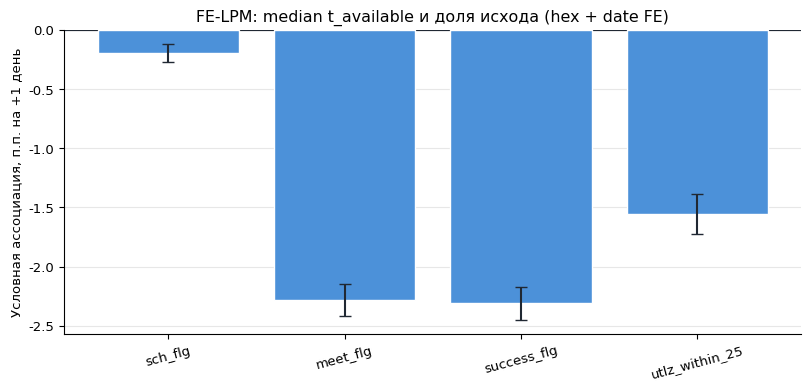

In [6]:
fe_rows = []

if apps.empty:
    display(Markdown("Dry-run: FE-LPM пропущен."))
else:
    try:
        from linearmodels.panel import PanelOLS
    except ImportError as exc:
        raise ImportError("Для FE-модели нужен linearmodels") from exc

    for outcome in BINARY_OUTCOMES:
        s = outcome_sample(assoc_base if outcome != "utlz_within_25" else assoc_utlz, outcome)
        if s.empty or outcome not in s.columns:
            print(f"[skip FE] {outcome}")
            continue

        panel = (
            s.groupby(["hex", "date"], as_index=False)
            .agg(
                y=(outcome, "mean"),
                median_t_available=("t_available_days", "median"),
                n_orders=("t_available_days", "count"),
            )
        )
        panel = panel.dropna(subset=["y", "median_t_available"])
        panel = panel.set_index(["hex", "date"]).sort_index()
        if len(panel) < 50:
            print(f"[skip FE] {outcome}: too few hex-day cells ({len(panel)})")
            continue

        mod = PanelOLS(
            dependent=panel["y"],
            exog=panel[["median_t_available"]],
            entity_effects=True,
            time_effects=True,
            drop_absorbed=True,
            check_rank=False,
        )
        res = mod.fit(cov_type="clustered", cluster_entity=True)
        beta = float(res.params["median_t_available"])
        se = float(res.std_errors["median_t_available"])
        ci_low = beta - 1.96 * se
        ci_high = beta + 1.96 * se
        pval = float(res.pvalues["median_t_available"])
        n_hexagons = int(panel.index.get_level_values("hex").nunique())
        row = {
            "section": "fe_lpm",
            "metric": "beta_median_t_available",
            "outcome": outcome,
            "estimate": beta,
            "std_error": se,
            "ci_lower": ci_low,
            "ci_upper": ci_high,
            "p_value": pval,
            "n_obs": int(res.nobs),
            "n_hexagons": n_hexagons,
            "estimator": "PanelOLS hex+date FE",
            "cluster_level": "hex",
            "unit": "outcome share (0-1) per +1 day",
            "note": "PanelOLS hex+date FE, cluster hex; conditional association",
        }
        # also report in percentage points per day
        row_pp = {
            **row,
            "metric": "beta_median_t_available_pp_per_day",
            "estimate": beta * 100,
            "std_error": se * 100,
            "ci_lower": ci_low * 100,
            "ci_upper": ci_high * 100,
            "unit": "percentage points per +1 day",
            "note": "percentage-point association per +1 day of median t_available",
        }
        fe_rows.extend([row, row_pp])
        summary_rows.extend([row, row_pp])
        print(
            f"{outcome}: beta={beta*100:+.3f} п.п./день "
            f"(se={se*100:.3f}, p={pval:.4g}, N={int(res.nobs)})"
        )

    fe_df = pd.DataFrame(fe_rows)
    display(fe_df)

    plot_df = fe_df[fe_df["metric"] == "beta_median_t_available_pp_per_day"].copy()
    if not plot_df.empty:
        fig, ax = plt.subplots(figsize=(8.2, 4.0))
        order = [o for o in BINARY_OUTCOMES if o in set(plot_df["outcome"])]
        plot_df = plot_df.set_index("outcome").reindex(order).reset_index()
        x = np.arange(len(plot_df))
        ax.bar(x, plot_df["estimate"], color=PALETTE["blue"], edgecolor="white", zorder=3)
        ax.errorbar(
            x, plot_df["estimate"],
            yerr=1.96 * plot_df["std_error"],
            fmt="none", ecolor=PALETTE["gray_dark"], capsize=4, zorder=4,
        )
        ax.axhline(0, color=PALETTE["gray_dark"], linewidth=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels(plot_df["outcome"], rotation=15)
        ax.set_ylabel("Условная ассоциация, п.п. на +1 день")
        ax.set_title("FE-LPM: median t_available и доля исхода (hex + date FE)")
        ax.grid(True, axis="y", alpha=0.3, zorder=0)
        fig.tight_layout()
        save_figure(fig, "speed_conversion_fe_lpm")
        plt.show()


## Сохранение сводной таблицы

Результат: `outputs/final/speed_conversion_association_summary.csv`.
Фигуры: `figures/empirical/speed_conversion_*.pdf/.png`.

In [7]:
summary = pd.DataFrame(summary_rows)
if summary.empty:
    summary = pd.DataFrame(
        [
            {
                "section": "status",
                "metric": "dry_run_or_no_data",
                "outcome": "",
                "estimate": np.nan,
                "std_error": np.nan,
                "p_value": np.nan,
                "n_obs": 0,
                "note": LOAD_ERROR or "no rows produced",
            }
        ]
    )

out_path = OUT_FINAL / "speed_conversion_association_summary.csv"
summary.to_csv(out_path, index=False)
print("Saved:", out_path.relative_to(PROJECT_ROOT))

fe_export = summary.loc[
    (summary["section"] == "fe_lpm")
    & (summary["metric"] == "beta_median_t_available_pp_per_day"),
    [
        "outcome", "estimate", "std_error", "ci_lower", "ci_upper",
        "p_value", "n_obs", "n_hexagons", "estimator",
        "cluster_level", "unit",
    ],
].rename(
    columns={
        "estimate": "estimate_pp_per_day",
        "std_error": "std_error_pp_per_day",
        "ci_lower": "ci_lower_pp_per_day",
        "ci_upper": "ci_upper_pp_per_day",
    }
)
fe_export[["n_obs", "n_hexagons"]] = fe_export[["n_obs", "n_hexagons"]].astype(int)
fe_path = OUT_FINAL / "speed_conversion_fe_summary.csv"
fe_export.to_csv(fe_path, index=False)
print("Saved:", fe_path.relative_to(PROJECT_ROOT))
display(summary)

display(Markdown(
    "**Напоминание:** все оценки в этом ноутбуке — **условные ассоциации**, "
    "а не причинно-следственные эффекты скорости назначения слота."
))

Saved: outputs\final\speed_conversion_association_summary.csv
Saved: outputs\final\speed_conversion_fe_summary.csv


               section                              metric         outcome       estimate  std_error  p_value    n_obs  \
0            selection                    n_total_requests                 1,807,317.0000        NaN      NaN  1807317   
1            selection        n_with_start_interval_nonneg                 1,694,859.0000        NaN      NaN  1694859   
2            selection             n_utlz_within_25_sample  utlz_within_25 1,470,084.0000        NaN      NaN  1470084   
3   descriptive_decile                conversion_spread_pp         sch_flg         2.7846        NaN      NaN  1694859   
4   descriptive_decile                conversion_spread_pp        meet_flg        14.8354        NaN      NaN  1665322   
5   descriptive_decile                conversion_spread_pp     success_flg        15.1203        NaN      NaN  1665322   
6   descriptive_decile                conversion_spread_pp  utlz_within_25         9.7323        NaN      NaN  1443638   
7          correlation  

**Напоминание:** все оценки в этом ноутбуке — **условные ассоциации**, а не причинно-следственные эффекты скорости назначения слота.

## Вывод

Более длинный `t_available` статистически связан с более низкими конверсиями: в FE-LPM оценки от −0.20 до −2.28 п.п. на дополнительный день медианной скорости (все p < 0.001). Это **условная ассоциация** при фиксированных FE гексагона и даты, а не доказательство каузального эффекта ускорения слота.